# **SPECTRA-CQ Synthetic Evaluation (Single Sensor `PE11`)**

This notebook implements an **Ensemble Evaluation Protocol**. For every architecture and noise level $\rightarrow$ the inference loop calculates the AUC-ROC across all three deterministic seeds (42, 100, 2026).
It then averages the Mean Squared Error (MSE) scores to generate a stable + reliable performance metric.

We evaluate the models against three progressive noise limits representing varying stages of incipient structural fatigue:
* **2% Noise (0.02):** Extreme early-stage micro-cracking.
* **5% Noise (0.05):** Intermediate localized degradation.
* **10% Noise (0.10):** Advanced localized degradation.

### **Objective**
To scientifically prove whether the extreme parameter efficiency of the quantum latent space acts as a geometric regularizer against overfitting.

We will inject mathematical structural degradation (Gaussian noise and frequency band masking) into unseen healthy spectrograms. We will evaluate three frozen architectures:
1. **Classical Baseline (CAE):** High parameter count. Susceptible to memorizing environmental noise.
2. **HQAE `none` (Depth 3):** The unentangled quantum champion from Phase 4a.
3. **HQAE `strong` (Depth 3):** The highly entangled quantum baseline.

**Evaluation Metric:** Area Under the Receiver Operating Characteristic Curve (AUC-ROC).

In [ ]:
import os
import glob
import torch
import numpy as np
from google.colab import drive

# 1. Mount Data Drive
drive.mount('/content/drive')

# 2. Clone Github Repository
GITHUB_TOKEN = "PAT" # Scrubbed for security
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt -q

# Append path to allow module imports
import sys
sys.path.append('/content/SPECTRA-CQ')

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 384, done.
remote: Counting objects: 100% (311/311), done.
remote: Compressing objects: 100% (202/202), done.
remote: Total 384 (delta 147), reused 253 (delta 90), pack-reused 73 (from 1)
Receiving objects: 100% (384/384), 36.64 MiB | 25.98 MiB/s, done.
Resolving deltas: 100% (157/157), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25

In [2]:
from sklearn.metrics import roc_curve, auc

from src.data.synthetic import prepare_evaluation_tensors
from src.engine.evaluator import AnomalyEvaluator
from src.models.classical.cae import ClassicalAutoencoder
from src.models.hybrid.hqae import HybridQuantumAutoencoder
from src.utils.viz import plot_roc_curve

In [3]:
# Hardware Verification
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing Inference on: {device}")

Executing Inference on: cuda


### **Data Ingestion (I/O Optimized)**

Streaming `.npy` binaries directly from Google Drive during inference heavily starves the GPU/CPU.
So we'll extract the compressed dataset directly to the Colab instance's local NVMe storage prior to executing the evaluation loop.

In [4]:
sys.path.append(os.path.abspath('.'))

DRIVE_ARCHIVE_PATH = "/content/drive/MyDrive/spectra-cq-data/spectra_matrices_PE11.zip"
LOCAL_DATA_DIR = "/content/local_spectra_data"
EXPECTED_DIR = f"{LOCAL_DATA_DIR}/processed_spectrograms_PE11"

# Extract to local NVMe
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
print("Extracting dataset (single sensor matrices) from Drive to local NVMe..")
!unzip -q {DRIVE_ARCHIVE_PATH} -d {LOCAL_DATA_DIR}

extracted_files = glob.glob(f"{LOCAL_DATA_DIR}/**/*.npy", recursive=True)
if extracted_files:
    actual_dir = os.path.dirname(extracted_files[0])
    if actual_dir != EXPECTED_DIR:
        print(f"Aligning nested directory structure..")
        os.makedirs(EXPECTED_DIR, exist_ok=True)
        !mv {actual_dir}/* {EXPECTED_DIR}/
        !rm -rf {LOCAL_DATA_DIR}/content

print("Data ready for inference.")

Extracting dataset (single sensor matrices) from Drive to local NVMe..
Aligning nested directory structure..
Data ready for inference.


### **Ensemble Evaluation Engine**

The following function acts as the core inference loop.

It dynamically generates synthetic anomalies (using `src.data.synthetic`) $\rightarrow$ initializes the requested architecture $\rightarrow$ maps the pre-trained weights for all deterministic seeds $\rightarrow$ and then computes the ensembled AUC-ROC score.

In [5]:
# Evaluation Protocol Constants
CHECKPOINT_BASE = "/content/drive/MyDrive/spectra-cq-data/checkpoints_phase3_PE11"
SEEDS = [42, 100, 2026]
NOISE_LEVELS = [0.02, 0.05, 0.1]

# Locate validation matrices (Subset isolated to prevent RAM saturation during memory-heavy evaluation)
val_files = glob.glob(f"{EXPECTED_DIR}/**/*.npy", recursive=True)[:200]
print(f"Loaded {len(val_files)} validation matrices for synthetic degradation testing.")

def evaluate_model_ensemble(model_class, model_kwargs, checkpoint_folder, noise_level, weight_filename="best_model.pth"):
    """
    Calculates the ensembled MSE anomaly scores across all seeds for a specific architecture.
    """
    # 1. Generate normal and degraded tensors dynamically
    t_healthy, t_damaged = prepare_evaluation_tensors(val_files, noise_factor=noise_level)

    # Ground truth labels: 0 for healthy baseline, 1 for synthetic anomaly
    y_true = np.concatenate([np.zeros(len(t_healthy)), np.ones(len(t_damaged))])

    all_scores = []

    for seed in SEEDS:
        model = model_class(**model_kwargs)

        # Map specific seed weights with dynamic filename
        weight_path = os.path.join(CHECKPOINT_BASE, checkpoint_folder, f"seed_{seed}", weight_filename)
        if not os.path.exists(weight_path):
            raise FileNotFoundError(f"Missing weights for {checkpoint_folder} (Seed {seed}) at {weight_path}")

        model.load_state_dict(torch.load(weight_path, map_location=device))

        # Execute Evaluation
        evaluator = AnomalyEvaluator(model, device)
        healthy_mse = evaluator.get_anomaly_scores(t_healthy)
        damaged_mse = evaluator.get_anomaly_scores(t_damaged)

        scores = np.concatenate([healthy_mse, damaged_mse])
        all_scores.append(scores)

    # Aggregate and average the MSE scores across the 3 seeds
    mean_scores = np.mean(all_scores, axis=0)

    # Calculate final ensembled AUC
    fpr, tpr, _ = roc_curve(y_true, mean_scores)
    ensemble_auc = auc(fpr, tpr)

    return ensemble_auc, mean_scores, y_true

Loaded 200 validation matrices for synthetic degradation testing.


## **Test 1: Incipient Damage (2% Noise)**
Simulating extreme early-stage micro-cracking bounded by routine environmental variance.

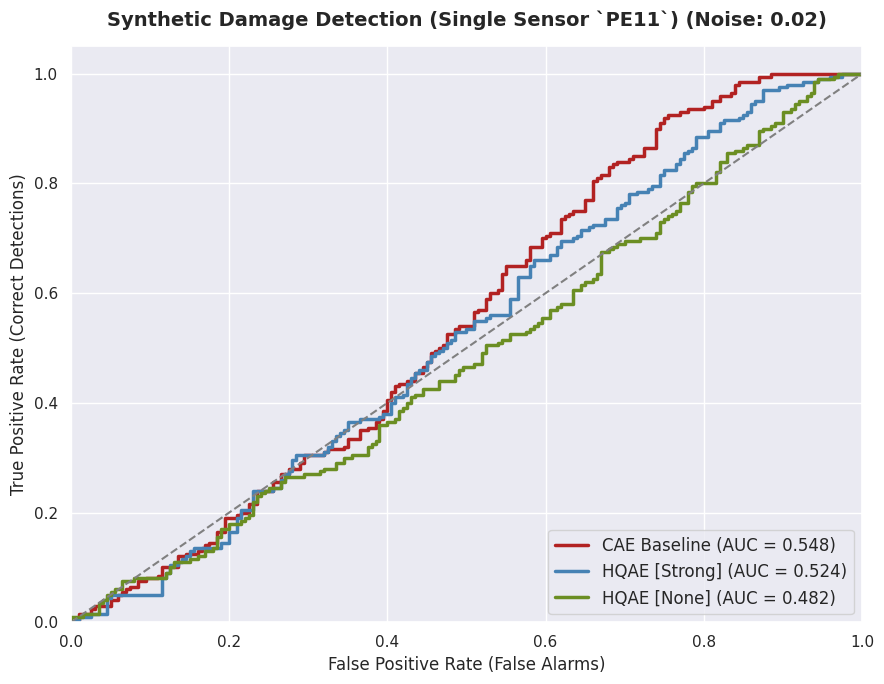

In [6]:
current_noise = 0.02

# 1. Classical Convolutional Autoencoder (CAE Baseline) - using specific filename
cae_auc, cae_scores, y_true = evaluate_model_ensemble(
    model_class=ClassicalAutoencoder,
    model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1},
    checkpoint_folder="classical",
    noise_level=current_noise,
    weight_filename="best_cae_model.pth"
)

# 2. Hybrid Quantum Autoencoder (Strong Entanglement)
hqae_strong_auc, hqae_strong_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder,
    model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'strong'},
    checkpoint_folder="quantum/strong_d3",
    noise_level=current_noise
)

# 3. Hybrid Quantum Autoencoder (Zero Entanglement)
hqae_none_auc, hqae_none_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder,
    model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'none'},
    checkpoint_folder="quantum/none_d3",
    noise_level=current_noise
)

plot_roc_curve(
    {"CAE Baseline": cae_scores, "HQAE [Strong]": hqae_strong_scores, "HQAE [None]": hqae_none_scores},
    y_true, title=f"Synthetic Damage Detection (Single Sensor `PE11`) (Noise: {current_noise})"
)

> NOTE :
> * AuC of `~1.000` is a massive red flag $\implies$ model detects damage too perfectly $\implies$ either data has leaked or the instance of damage is too big and easy to guess
> * AuC of `~0.500` $\implies$ a random guess
> * AuC `less than 0.500` $\implies$ performance is even worse than a 50-50nrandom guess
> * We aim for an ideal model with AuC `between 0.90 to 0.98`

## **Test 2: Intermediate Damage (5% Noise)**
Simulating progressing structural stiffness loss.

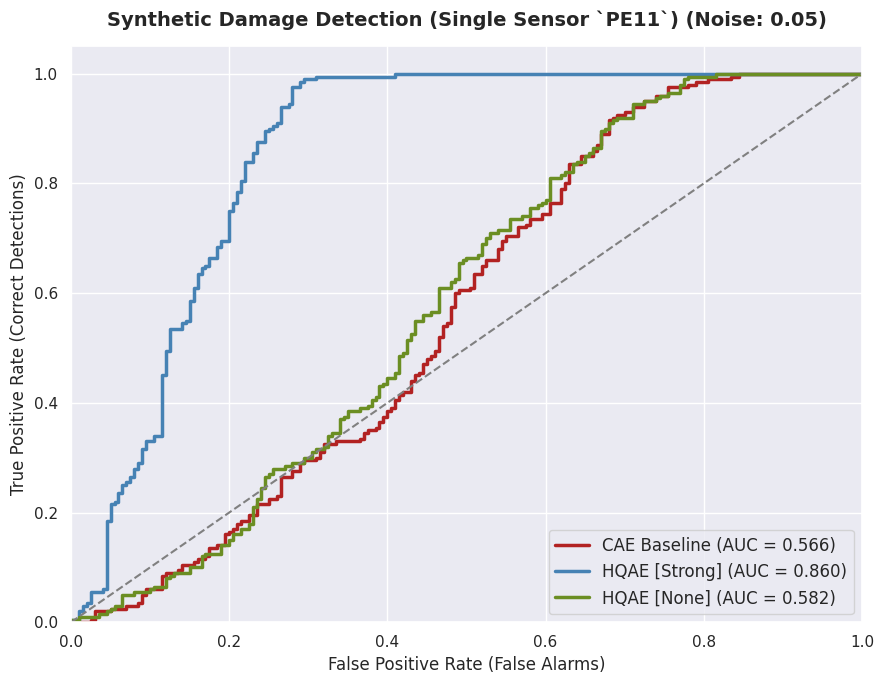

In [9]:
current_noise = 0.05

cae_auc, cae_scores, y_true = evaluate_model_ensemble(
    model_class=ClassicalAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1},
    checkpoint_folder="classical", noise_level=current_noise, weight_filename="best_cae_model.pth"
)

hqae_strong_auc, hqae_strong_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'strong'},
    checkpoint_folder="quantum/strong_d3", noise_level=current_noise
)

hqae_none_auc, hqae_none_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'none'},
    checkpoint_folder="quantum/none_d3", noise_level=current_noise
)

plot_roc_curve(
    {"CAE Baseline": cae_scores, "HQAE [Strong]": hqae_strong_scores, "HQAE [None]": hqae_none_scores},
    y_true, title=f"Synthetic Damage Detection (Single Sensor `PE11`) (Noise: {current_noise})"
)

## **Test 3: Advanced Damage (10% Noise)**
Simulating highly localized structural failure nearing a catastrophic threshold.

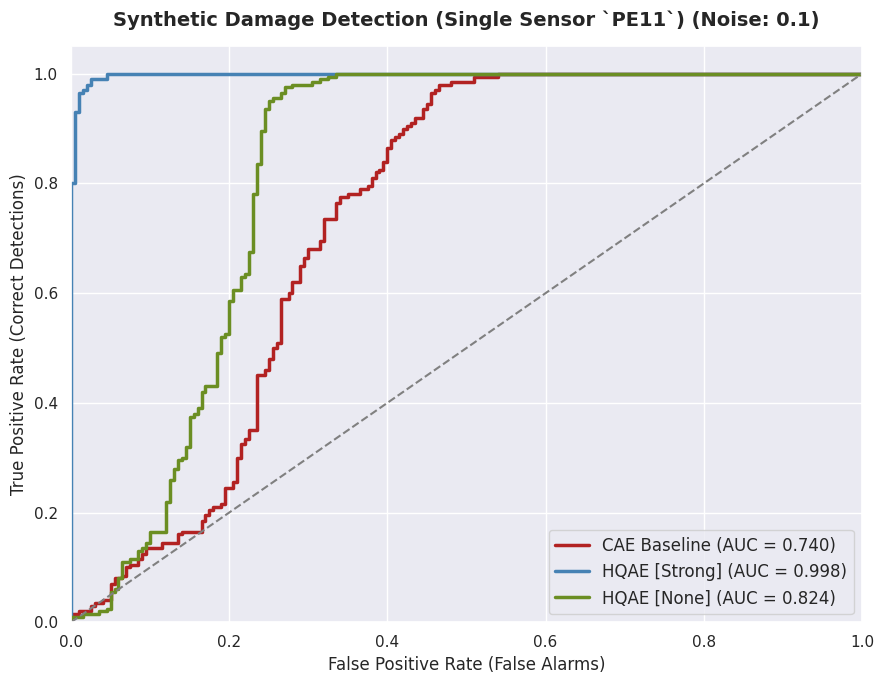

In [10]:
current_noise = 0.10

cae_auc, cae_scores, y_true = evaluate_model_ensemble(
    model_class=ClassicalAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1},
    checkpoint_folder="classical", noise_level=current_noise, weight_filename="best_cae_model.pth"
)

hqae_strong_auc, hqae_strong_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'strong'},
    checkpoint_folder="quantum/strong_d3", noise_level=current_noise
)

hqae_none_auc, hqae_none_scores, _ = evaluate_model_ensemble(
    model_class=HybridQuantumAutoencoder, model_kwargs={'latent_dim_per_sensor': 8, 'num_sensors': 1, 'n_quantum_layers': 3, 'topology': 'none'},
    checkpoint_folder="quantum/none_d3", noise_level=current_noise
)

plot_roc_curve(
    {"CAE Baseline": cae_scores, "HQAE [Strong]": hqae_strong_scores, "HQAE [None]": hqae_none_scores},
    y_true, title=f"Synthetic Damage Detection (Single Sensor `PE11`) (Noise: {current_noise})"
)

## **Empirical Observations**

The multi-noise ablation study yields a definitive physical and architectural boundary for localized Structural Health Monitoring (SHM) systems.

AUC-ROC observations across 3 noise thresholds:

### **1. Advanced Degradation (10% Noise)**
At a noise level of **0.10** $\rightarrow$ the structural degradation is profound enough to dominate ambient variance.
* **CAE Baseline:** AUC = 0.740
* **HQAE [`None`]:** AUC = 0.824
* **HQAE [`Strong`]:** AUC = 0.998

The quantum advantage is highly visible here. The heavily entangled HQAE [Strong] achieves near-perfect detection (0.998) $\leftarrow$ significantly outperforms the classical convolutional baseline.

### **2. Intermediate Degradation (5% Noise)**
At a noise level of **0.05** $\rightarrow$ simulates progressing structural stiffness loss. Here, the performance gap widens:
* **CAE Baseline:** AUC = 0.566
* **HQAE [`None`]:** AUC = 0.582
* **HQAE [`Strong`]:** AUC = 0.860

The HQAE with strong spatial entanglement topology maintains robust predictive capacity (0.860). The classical CAE and the zero-entanglement HQAE drop toward random guessing.

This highlights the capability of parameterized quantum circuits to map complex latent spaces efficiently compared to dense classical bottlenecks.

### **3. Incipient Damage (2% Noise)**
The true test of an SHM system is its ability to detect early-stage micro-cracking (0.02 noise).

At this threshold, the performance of all single-sensor models collapsed to near-random guessing:
* **CAE Baseline:** AUC = 0.548
* **HQAE [`None`]:** AUC = 0.482
* **HQAE [`Strong`]:** AUC = 0.524

#### **Interpretation of scores**
* **The Classical CAE (Memorization):**
  * Classical CAE has thousands of trainable weights (over-parameterized)
  * This over-parameterization has a tendency to memorize complex noise patterns.
  * It managed to slightly differentiate the 2% synthetic mathematical noise from the natural environmental baseline $\implies$ resulted in a marginal (but practically useless) bump above 0.500.
* **The HQAE [None] (Regularization):**
  * Hybrid HQAE has only only 24 parameters
  * Also, the unentangled topology acts as an extreme geometric regularizer
  * It aggressively smoothed out the 2% anomaly $\rightarrow$ treating it as standard environmental variance (such as a gust of wind).
  * It completely smoothed the damage away because a single sensor did not provide enough context to validate it as a structural failure.

## **Conclusion: Single-Sensor Limit and the Pivot to Phase 4**

The inability of all models to reliably detect 2% degradation is not a failure of the neural architectures $\rightarrow$ but rather a fundamental physical limitation of localized telemetry.

* **Single-Sensor Paradox:**
  * A single accelerometer simply lacks the necessary signal-to-noise ratio and spatial context to mathematically distinguish a localized early-stage micro-crack from routine global environmental variance (e.g., a heavy gust of wind or an ambient temperature shift).
  * The sensor detects a change in vibration $\leftarrow$ but cannot determine if the change is structural or environmental.

* **Phase 4 Directive (Multi-Sensor Spatial Fusion):**
  * The architecture cannot just be "deeper" to detect incipient damage $\leftarrow$ it must possess spatial awareness.
  * We must transition from a 1-Dimensional localized view to a global spatio-temporal mapping of the entire bridge structure.

In Phase 4, we will upgrade the architecture to ingest a synchronized tensor from 6 distinct sybnchronized physical sensors (`PE11`, `PE12`, `PE13`, `PE21`, `PE22`, `PE23`) simultaneously.

By correlating the frequency behaviors across multiple physical nodes $\rightarrow$ the network can theoretically learn to cancel out global environmental noise (which affects all sensors equally) and isolate the localized anomalies of micro-cracking. This sets the stage to evaluate whether custom, physics-informed Quantum Graph Topologies can efficiently map these complex inter-sensor relationships.